# Task 1 - Student Score Prediction

## 1- Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

## 2- Load the Dataset

The dataset contains information about students, such as study hours, attendance, previous scores, tutoring sessions, and other factors.

The target variable is **Exam_Score**.


In [2]:
df = pd.read_csv("data/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 3- Initial Data Inspection

Before cleaning the data, I first inspect its structure, size, data types, missing values, duplicate rows, and basic statistics.

This helps identify possible problems that need to be handled before building the model.


In [3]:
df.shape

(6607, 20)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 4- Data Cleaning

Data cleaning is important before training a machine learning model.

In this step, I check:

* Missing values
* Invalid values
* Outliers
* Data ranges

I do not remove every statistical outlier automatically. Some unusual values can still be valid observations.


### 4.1 Missing Values

The dataset contains missing values in some categorical columns.

I first check the categories and their frequencies to decide how to handle the missing values.


In [8]:
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Teacher_Quality
Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64

Parental_Education_Level
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
NaN               90
Name: count, dtype: int64

Distance_from_Home
Distance_from_Home
Near        3884
Moderate    1998
Far          658
NaN           67
Name: count, dtype: int64


For these categorical columns, I use the **mode** to fill the missing values because the mode represents the most common category in each column.

In [9]:
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    print(col, "→", df[col].mode()[0])

Teacher_Quality → Medium
Parental_Education_Level → High School
Distance_from_Home → Near


In [10]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0])

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0])

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0])

### 4.2 Invalid Values

The **Exam_Score** should logically be between 0 and 100.

I check whether there are values greater than 100.


In [11]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


One record has an **Exam_Score of 101**, which is outside the valid range of exam scores.

Since this is an invalid value rather than a valid extreme observation, I correct it to **100**, the maximum possible score.

In [12]:
df.loc[df["Exam_Score"] > 100, "Exam_Score"] = 100

### 4.3 Outlier Detection

I use the **Interquartile Range (IQR)** method to detect statistical outliers.

The IQR is calculated as:

**IQR = Q3 - Q1**

The lower and upper bounds are:

**Lower Bound = Q1 - 1.5 × IQR**

**Upper Bound = Q3 + 1.5 × IQR**

A value outside these bounds is considered a statistical outlier.

However, a statistical outlier is not necessarily an error. I inspect the detected values before deciding whether to remove or modify them.


In [13]:
numeric_cols = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)]

    print(f"{col}:")
    print(f"  Lower bound = {lower_bound:.2f}")
    print(f"  Upper bound = {upper_bound:.2f}")
    print(f"  Outliers = {len(outliers)}")
    print()

Hours_Studied:
  Lower bound = 4.00
  Upper bound = 36.00
  Outliers = 43

Attendance:
  Lower bound = 40.00
  Upper bound = 120.00
  Outliers = 0

Sleep_Hours:
  Lower bound = 3.00
  Upper bound = 11.00
  Outliers = 0

Previous_Scores:
  Lower bound = 25.50
  Upper bound = 125.50
  Outliers = 0

Tutoring_Sessions:
  Lower bound = -0.50
  Upper bound = 3.50
  Outliers = 430

Physical_Activity:
  Lower bound = -1.00
  Upper bound = 7.00
  Outliers = 0

Exam_Score:
  Lower bound = 59.00
  Upper bound = 75.00
  Outliers = 104



### 4.4 Inspect Important Outliers

Some columns contain values that are statistically unusual according to the IQR method.

I inspect these values before removing them because they may represent real students rather than data errors.


In [14]:
df.loc[
    (df["Hours_Studied"] < 4) |
    (df["Hours_Studied"] > 36),
    "Hours_Studied"].value_counts().sort_index()

Hours_Studied
1      3
2      6
3     12
37     6
38     7
39     7
43     1
44     1
Name: count, dtype: int64

The extreme study-hour values are unusual but still possible, so they are kept.

In [15]:
df["Tutoring_Sessions"].value_counts().sort_index()

Tutoring_Sessions
0    1513
1    2179
2    1649
3     836
4     301
5     103
6      18
7       7
8       1
Name: count, dtype: int64

Higher numbers of tutoring sessions are less common, but they are still realistic values. Therefore, they are kept.

In [16]:
df.loc[
    (df["Exam_Score"] < 59) |
    (df["Exam_Score"] > 75),
    "Exam_Score"].value_counts().sort_index()

Exam_Score
55      1
56      1
57      4
58     22
76     16
77      5
78      4
79      3
80      5
82      4
83      1
84      3
85      1
86      4
87      2
88      3
89      3
91      1
92      2
93      2
94      4
95      2
96      1
97      3
98      3
99      2
100     2
Name: count, dtype: int64

The exam scores outside the IQR bounds are statistically unusual, but most of them are still valid scores.

The only clearly invalid value was **101**, which was already corrected to 100.

Therefore, valid scores are kept rather than being removed only because they are statistical outliers.


### 4.5 Final Data Validation

After cleaning, I check that there are no remaining missing values and that the exam score is within the valid range.


In [17]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [18]:
df["Exam_Score"].min(), df["Exam_Score"].max()

(np.int64(55), np.int64(100))

In [19]:
for col in numeric_cols:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

Hours_Studied: min = 1, max = 44
Attendance: min = 60, max = 100
Sleep_Hours: min = 4, max = 10
Previous_Scores: min = 50, max = 100
Tutoring_Sessions: min = 0, max = 8
Physical_Activity: min = 0, max = 6
Exam_Score: min = 55, max = 100


The dataset is now clean:

* Missing categorical values were filled using the mode.
* No duplicate rows were found.
* The invalid exam score of 101 was corrected to 100.
* Other statistical outliers were inspected and kept because they represent plausible observations.


## 5- Exploratory Data Analysis

After cleaning the data, I explore the relationship between study hours and exam scores.

The goal is to understand the data before training the model.


### 5.1 Hours Studied vs Exam Score

A scatter plot is used to visualize the relationship between **Hours Studied** and **Exam Score**.


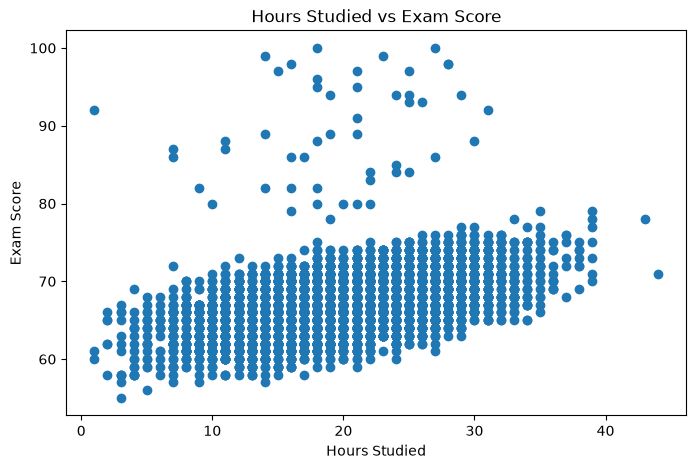

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Hours_Studied"],
    df["Exam_Score"])

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")

plt.show()

The scatter plot shows a **positive relationship** between study hours and exam scores.

However, the points are spread out, which means that study hours alone do not completely explain exam performance.


### 5.2 Correlation

I calculate the correlation between study hours and exam score to measure the strength and direction of their linear relationship.


In [21]:
df["Hours_Studied"].corr(df["Exam_Score"])

np.float64(0.4455575850232126)

The correlation is around **0.45**, which indicates a **moderate positive relationship**.

This means that students who study more hours tend to have higher exam scores, but there are other factors that also affect their performance.


### 5.3 Exam Score Distribution

A histogram is used to understand how exam scores are distributed across the students.


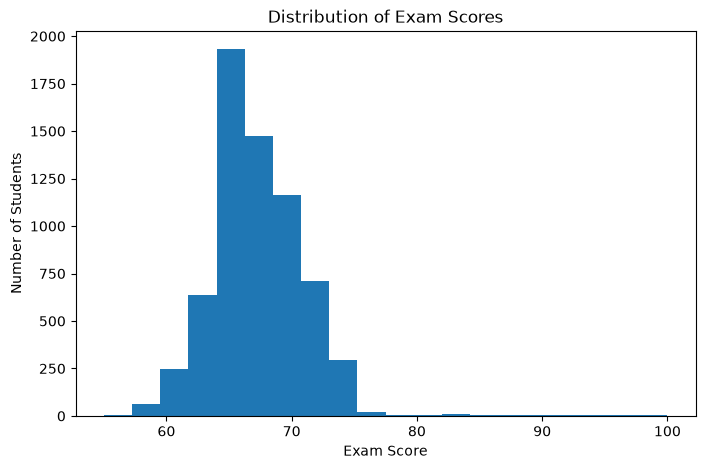

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(df["Exam_Score"], bins=20)

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()

Most exam scores are concentrated in the middle range, especially around the mid-60s to 70s.

Very high scores are less common.

### 5.4 Study Hours Distribution

I also examine the distribution of study hours to understand the typical number of hours students study.


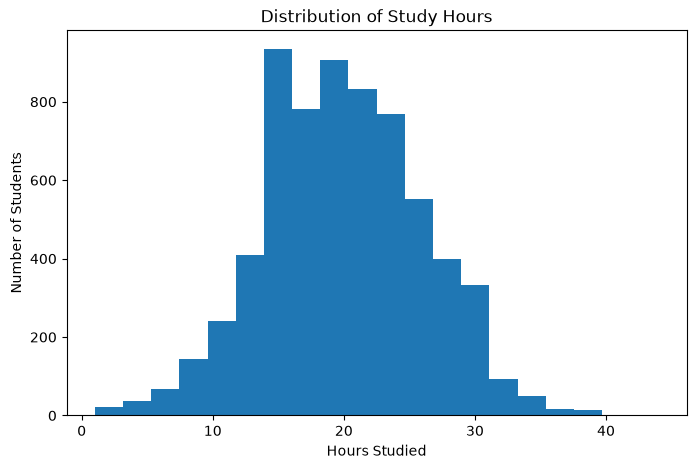

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["Hours_Studied"], bins=20)

plt.xlabel("Hours Studied")
plt.ylabel("Number of Students")
plt.title("Distribution of Study Hours")

plt.show()

Most students study within the middle range of the dataset.

There are fewer students at very low or very high study hours.

### 5.5 Average Exam Score by Study Hours

I calculate the average exam score for each number of study hours to observe the overall trend.

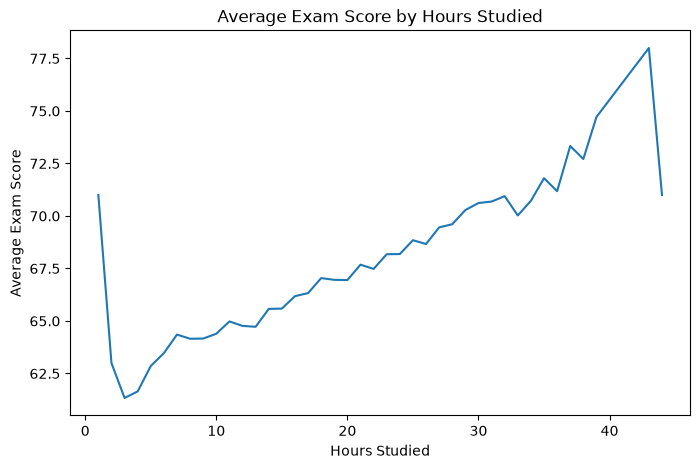

In [24]:
mean_scores = df.groupby("Hours_Studied")["Exam_Score"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    mean_scores.index,
    mean_scores.values)

plt.xlabel("Hours Studied")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Hours Studied")

plt.show()

The average exam score generally increases as study hours increase, although the trend is not perfectly smooth.

This supports the idea that Hours Studied can be useful for predicting exam scores.

## 6- Baseline Model: Linear Regression

For the baseline model, I use only **Hours_Studied** to predict **Exam_Score**.

This gives a simple starting point that can later be compared with more advanced feature combinations.


In [25]:
X = df[["Hours_Studied"]]
y = df["Exam_Score"]

### 6.1 Train/Test Split

I split the dataset into training and testing sets.

* **80%** of the data is used for training.
* **20%** is used for testing.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5285, 1)
X_test shape: (1322, 1)
y_train shape: (5285,)
y_test shape: (1322,)


### 6.2 Train the Linear Regression Model

I use Linear Regression to learn the relationship between study hours and exam scores.


In [27]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.29]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours_Studied']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,61.51
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [28]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.2856316897148276
Intercept: 61.511718128884226


The model learns an equation of the form:

**Exam Score = Intercept + Coefficient × Hours Studied**

The coefficient is positive, which means that the predicted exam score increases as study hours increase.


### 6.3 Make Predictions

In [29]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Actual Scores:")
print(y_test.head(10).values)

First 10 Predictions:
[67.22435192 67.7956153  67.50998361 64.93929841 67.50998361 67.50998361
 72.08009065 68.36687868 66.36745685 66.08182516]

First 10 Actual Scores:
[65 65 71 64 66 66 72 66 70 70]


### 6.4 Model Evaluation

I use four evaluation metrics:

* **MAE:** Average absolute prediction error.
* **MSE:** Average squared error.
* **RMSE:** Error in the same unit as the target.
* **R²:** Percentage of variation explained by the model.


In [30]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2.4475746204358835
MSE: 10.85600391840213
RMSE: 3.2948450522599892
R²: 0.23198102173895396


The baseline model achieved:

* **MAE ≈ 2.45**
* **RMSE ≈ 3.29**
* **R² ≈ 0.23**

The R² score shows that study hours alone explain about **23% of the variation** in exam scores.

This suggests that other student factors are also important.


### 6.5 Actual vs Predicted Exam Scores

I compare the actual exam scores with the predicted scores using a scatter plot.


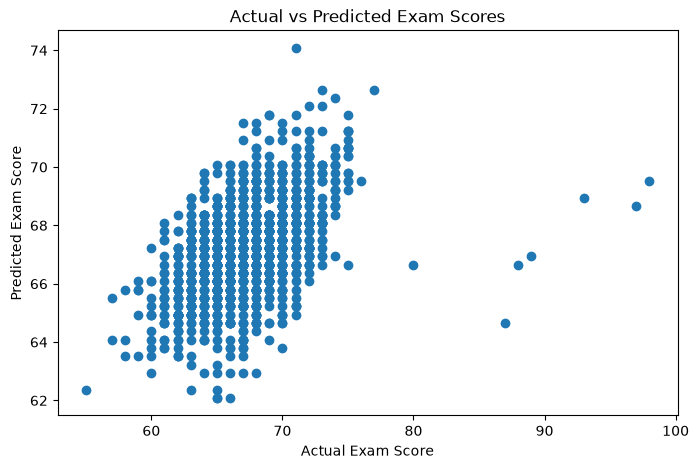

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

The predictions show a positive relationship with the actual scores, but the predicted values are concentrated in a relatively narrow range.

Some high exam scores are underestimated because the model uses only **Hours Studied**.


# 7- Bonus 1: Multiple Linear Regression

The baseline model uses only one feature.

In this bonus, I add more numerical features that may affect exam performance and build a **Multiple Linear Regression** model.

The selected features are:

* Hours Studied
* Attendance
* Sleep Hours
* Previous Scores
* Tutoring Sessions
* Physical Activity


In [32]:
features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"]

X_multi = df[features]
y_multi = df["Exam_Score"]

print(X_multi.head())
print(X_multi.shape)

   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             23          84            7               73                  0   
1             19          64            8               59                  2   
2             24          98            7               91                  2   
3             29          89            8               98                  1   
4             19          92            6               65                  3   

   Physical_Activity  
0                  3  
1                  4  
2                  4  
3                  4  
4                  4  
(6607, 6)


In [33]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42)

print("X_train_multi shape:", X_train_multi.shape)
print("X_test_multi shape:", X_test_multi.shape)
print("y_train_multi shape:", y_train_multi.shape)
print("y_test_multi shape:", y_test_multi.shape)

X_train_multi shape: (5285, 6)
X_test_multi shape: (1322, 6)
y_train_multi shape: (5285,)
y_test_multi shape: (1322,)


In [34]:
multi_model = LinearRegression()

multi_model.fit(
    X_train_multi,
    y_train_multi)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.29, 0.2 ,-0.03, 0.05, 0.51, 0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores', 'Tutoring_Sessions','Physical_Activity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,40.98
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [35]:
print("Intercept:", multi_model.intercept_)

for feature, coefficient in zip(
    features,
    multi_model.coef_):
    print(feature, ":", coefficient)

Intercept: 40.978559636450726
Hours_Studied : 0.2892300116818179
Attendance : 0.19864185107376062
Sleep_Hours : -0.03343721363958932
Previous_Scores : 0.04819404630437331
Tutoring_Sessions : 0.5094271651025222
Physical_Activity : 0.15109792121996635


The Multiple Linear Regression model uses several student-related factors at the same time.

The coefficients show the model's learned relationship between each feature and the exam score while keeping the other selected features constant.

For example, the positive coefficient for **Hours_Studied** means that, within this model, higher study hours are associated with higher predicted exam scores.


In [36]:
y_pred_multi = multi_model.predict(X_test_multi)

print("First 10 Predictions:")
print(y_pred_multi[:10])

print("\nFirst 10 Actual Scores:")
print(y_test_multi.head(10).values)

First 10 Predictions:
[66.0904696  67.25519753 68.44518043 66.76633995 65.65210713 68.0314836
 70.15756881 67.33131908 68.90307016 67.94258226]

First 10 Actual Scores:
[65 65 71 64 66 66 72 66 70 70]


In [37]:
mae_multi = mean_absolute_error(
    y_test_multi,
    y_pred_multi)

mse_multi = mean_squared_error(
    y_test_multi,
    y_pred_multi)

rmse_multi = mean_squared_error(
    y_test_multi,
    y_pred_multi) ** 0.5

r2_multi = r2_score(
    y_test_multi,
    y_pred_multi)

print("MAE:", mae_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R²:", r2_multi)

MAE: 1.2658202813013728
MSE: 5.065323302029735
RMSE: 2.2506273130018073
R²: 0.6416485793273974


The Multiple Linear Regression model performed much better than the baseline model.

Its results were approximately:

* **MAE = 1.27**
* **RMSE = 2.25**
* **R² = 0.64**

The improvement shows that adding relevant features provides much more useful information than using study hours alone.


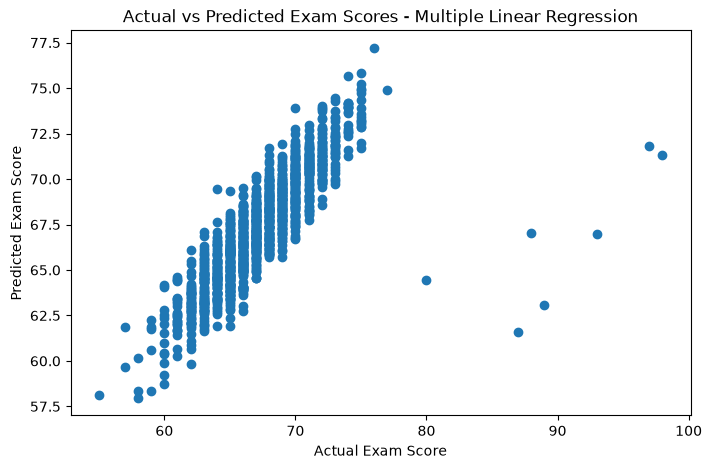

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_multi,
    y_pred_multi)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title(
    "Actual vs Predicted Exam Scores - Multiple Linear Regression")

plt.show()

The Multiple Linear Regression model produces predictions that are more spread out and closer to the actual scores compared with the baseline model.

However, some high exam scores are still underestimated, which suggests that additional features may further improve the model.


# 8- Bonus 2: Polynomial Regression

Polynomial Regression is tested to determine whether a curved relationship between **Hours Studied** and **Exam Score** can improve the baseline model.

I use:

* Degree 2
* Degree 3

Only **Hours_Studied** is used here so that the polynomial models can be fairly compared with the original single-feature Linear Regression model.


## 8.1 Polynomial Regression - Degree 2

A degree-2 polynomial adds a squared version of the feature:

**Exam Score = b₀ + b₁X + b₂X²**

`PolynomialFeatures` is used to create the polynomial features.


In [39]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

print("Original features:", X_train.shape)
print("Polynomial features:", X_train_poly.shape)

Original features: (5285, 1)
Polynomial features: (5285, 3)


The original dataset has one feature:

**Hours_Studied**

After applying degree-2 polynomial transformation, the model receives:

* 1
* Hours_Studied
* Hours_Studied²

The transformation is fitted only on the training data and then applied to the test data.


In [40]:
poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0. ,0.23,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,61.99
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[17785.1 , 89.95, 0. ]"


In [41]:
y_pred_poly = poly_model.predict(X_test_poly)

print("First 10 Predictions:")
print(y_pred_poly[:10])

print("\nFirst 10 Actual Scores:")
print(y_test.head(10).values)

First 10 Predictions:
[67.17737158 67.75404615 67.46440064 64.97533141 67.46440064 67.46440064
 72.41270323 68.34118654 66.33198312 66.05541987]

First 10 Actual Scores:
[65 65 71 64 66 66 72 66 70 70]


In [42]:
mae_poly = mean_absolute_error(
    y_test,
    y_pred_poly)

mse_poly = mean_squared_error(
    y_test,
    y_pred_poly)

rmse_poly = mean_squared_error(
    y_test,
    y_pred_poly) ** 0.5

r2_poly = r2_score(
    y_test,
    y_pred_poly)

print("MAE:", mae_poly)
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)

MAE: 2.444785842952146
MSE: 10.845073854025323
RMSE: 3.2931859731915116
R²: 0.23275428019925837


The Degree-2 Polynomial Regression model gives almost the same results as the baseline Linear Regression model.

This means that adding a squared study-hours term does not significantly improve the predictions.


## 8.2 Polynomial Regression — Degree 3

A degree-3 polynomial adds both squared and cubed versions of the feature:

**Exam Score = b₀ + b₁X + b₂X² + b₃X³**


In [43]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)

X_test_poly3 = poly3.transform(X_test)

print("Original features:", X_train.shape)
print(
    "Polynomial Degree 3 features:",
    X_train_poly3.shape)

Original features: (5285, 1)
Polynomial Degree 3 features: (5285, 4)


In [44]:
poly3_model = LinearRegression()

poly3_model.fit(
    X_train_poly3,
    y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. , 0.22, 0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,62.03
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[610524.82, 3082.11, 31.07, 0. ]"


In [45]:
y_pred_poly3 = poly3_model.predict(
    X_test_poly3
)

print("First 10 Predictions:")
print(y_pred_poly3[:10])

print("\nFirst 10 Actual Scores:")
print(y_test.head(10).values)

First 10 Predictions:
[67.17730424 67.75564037 67.46518632 64.97262103 67.46518632 67.46518632
 72.38831875 68.3440716  66.32957168 66.05245936]

First 10 Actual Scores:
[65 65 71 64 66 66 72 66 70 70]


In [46]:
mae_poly3 = mean_absolute_error(
    y_test,
    y_pred_poly3)

mse_poly3 = mean_squared_error(
    y_test,
    y_pred_poly3)

rmse_poly3 = mean_squared_error(
    y_test,
    y_pred_poly3) ** 0.5

r2_poly3 = r2_score(
    y_test,
    y_pred_poly3)

print("MAE:", mae_poly3)
print("MSE:", mse_poly3)
print("RMSE:", rmse_poly3)
print("R²:", r2_poly3)

MAE: 2.4445277195626294
MSE: 10.843961583896235
RMSE: 3.2930170943826322
R²: 0.23283296887462301


The Degree-3 Polynomial Regression model performs slightly better than Degree 2, but the improvement is extremely small.

Therefore, increasing the polynomial degree does not provide a meaningful improvement for this dataset when using only **Hours_Studied**.


# 9- Model Comparison

I compare all the models using MAE, MSE, RMSE, and R².

Lower MAE, MSE, and RMSE indicate smaller prediction errors.

Higher R² indicates that the model explains more variation in exam scores.


In [47]:
comparison = {
    "Linear Regression": [
        mae,
        mse,
        rmse,
        r2],

    "Polynomial Degree 2": [
        mae_poly,
        mse_poly,
        rmse_poly,
        r2_poly],

    "Polynomial Degree 3": [
        mae_poly3,
        mse_poly3,
        rmse_poly3,
        r2_poly3],

    "Multiple Linear Regression": [
        mae_multi,
        mse_multi,
        rmse_multi,
        r2_multi]}

comparison_df = pd.DataFrame(
    comparison,
    index=["MAE", "MSE", "RMSE", "R²"]).T

comparison_df

,MAE,MSE,RMSE,R²
Linear Regression,2.447575,10.856004,3.294845,0.231981
Polynomial Degree 2,2.444786,10.845074,3.293186,0.232754
Polynomial Degree 3,2.444528,10.843962,3.293017,0.232833
Multiple Linear Regression,1.265820,5.065323,2.250627,0.641649


### Comparison

The results show that **Multiple Linear Regression** is clearly the best-performing model.

The baseline Linear Regression model achieved an R² of about **0.23**, while the Multiple Linear Regression model achieved about **0.64**.

Polynomial Regression with Degrees 2 and 3 produced only very small improvements over the baseline.

This shows that adding relevant features was much more useful than simply increasing the polynomial complexity of the model.


# 10- Final Conclusion

This project used the Student Performance Factors dataset to predict students' exam scores.

The data was first inspected and cleaned by handling missing values, checking duplicates, validating value ranges, and inspecting statistical outliers. The invalid exam score of 101 was corrected to 100, while other unusual but valid observations were kept.

Exploratory Data Analysis showed a moderate positive relationship between **Hours Studied** and **Exam Score**.

A baseline Linear Regression model using only **Hours Studied** achieved an MAE of about **2.45** and an R² of about **0.23**.

After adding more relevant numerical features, the Multiple Linear Regression model achieved an MAE of about **1.27**, an RMSE of about **2.25**, and an R² of about **0.64**.

Polynomial Regression with Degrees 2 and 3 was also tested, but it produced only a very small improvement compared with the baseline.

### Final Finding

The **Multiple Linear Regression model performed best**.

The results show that exam performance depends on more than just study hours. Adding relevant student-related features provided a much larger improvement than increasing model complexity with polynomial features.


### Saving the Trained Model

so they can be reused later in the Streamlit application without retraining the model.

In [48]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    {
        "model": multi_model,
        "features": features
    },
    "artifacts/student_score_model.pkl"
)

['artifacts/student_score_model.pkl']